# 🍎 AppleAI Pro — Complete Pipeline
### Apple Leaf Disease Detection | MobileNetV2 + Grad-CAM + Streamlit

---
**How to use:**
1. Upload `apple_plantvillage.zip` and `plantdoc.zip` to `/content/` in Colab
2. Go to **Runtime → Change runtime type → T4 GPU**
3. Run all cells top to bottom (**Runtime → Run all**)

---
| Cell | What it does |
|------|--------------|
| 1 | Install packages |
| 2 | Imports & config |
| 3 | Extract & merge datasets |
| 4 | Data loaders + augmentation |
| 5 | Model setup |
| 6 | Training loop |
| 7 | Plots |
| 8 | Test evaluation |
| 9 | Write Streamlit app |
| 10 | Launch app via ngrok |

## 📦 Cell 1 — Install Packages

In [1]:
# Takes ~60 seconds on Colab
!pip install -q torch torchvision streamlit opencv-python-headless \
               Pillow scikit-learn seaborn matplotlib pyngrok
print('✅ All packages ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.6 MB/s eta 0:00:00
✅ All packages ready.


## 🔧 Cell 2 — Imports & Global Config

In [2]:
import os, shutil, warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image, UnidentifiedImageError
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Global config ─────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES     = ['black_rot', 'healthy', 'rust', 'scab']
FINAL_PATH  = 'data/final'
IMG_SIZE    = 224
BATCH       = 32
MAX_EPOCHS  = 50
PATIENCE    = 7      # early stopping
LR          = 1e-4
WD          = 1e-5   # weight decay

# ImageNet normalisation
NORM = transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])

print(f'✅ Device : {DEVICE}')
print(f'   PyTorch: {torch.__version__}')

✅ Device : cuda
   PyTorch: 2.11.0+cu128


## 📂 Cell 3 — Extract Datasets & Merge

In [3]:
# ── 3a. Clean workspace ───────────────────────────────────────
for p in ['data/plantvillage', 'data/plantdoc', FINAL_PATH]:
    if os.path.exists(p):
        shutil.rmtree(p)
    os.makedirs(p, exist_ok=True)

print('📦 Unzipping ...')
!unzip -q "/content/apple_plantvillage.zip" -d data/plantvillage
!unzip -q "/content/plantdoc.zip"           -d data/plantdoc
print('✅ Extraction done.')

# ── 3b. Image validation helper ───────────────────────────────
def is_valid_image(path):
    """
    verify() exhausts the file pointer — always re-open
    after to confirm the full image is decodable.
    """
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            im.load()
        return True
    except Exception:
        return False

# ── 3c. Merge PlantVillage + PlantDoc ─────────────────────────
KEYWORD_MAP = {
    'scab'   : 'scab',
    'rot'    : 'black_rot',
    'rust'   : 'rust',
    'healthy': 'healthy',
}

def process_folder(root_dir, prefix):
    copied, skipped = 0, 0
    for root, _, files in os.walk(root_dir):
        imgs = [f for f in files
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not imgs:
            continue

        dirname = os.path.basename(root).lower()
        target  = next((v for k, v in KEYWORD_MAP.items()
                        if k in dirname), None)
        if target is None:
            continue

        # 80 / 10 / 10 stratified split
        tr, tmp = train_test_split(imgs, test_size=0.20, random_state=42)
        vl, ts  = train_test_split(tmp,  test_size=0.50, random_state=42)

        for split, flist in zip(['train', 'val', 'test'], [tr, vl, ts]):
            dest = f'{FINAL_PATH}/{split}/{target}'
            os.makedirs(dest, exist_ok=True)
            for f in flist:
                src = os.path.join(root, f)
                if is_valid_image(src):
                    shutil.copy(src, f'{dest}/{prefix}_{f}')
                    copied += 1
                else:
                    skipped += 1

    print(f'  [{prefix.upper()}] copied={copied:,}  skipped(corrupt)={skipped}')
    return copied

c1 = process_folder('data/plantvillage', 'pv')
c2 = process_folder('data/plantdoc',     'pd')
total = c1 + c2
print(f'\n✅ Total images merged: {total:,}  (PV={c1:,}  PD={c2:,})')
assert total > 0, '❌ No images found — check your zip file names!'

# Quick per-split count
for split in ['train', 'val', 'test']:
    n = sum(len(os.listdir(f'{FINAL_PATH}/{split}/{c}'))
            for c in CLASSES
            if os.path.isdir(f'{FINAL_PATH}/{split}/{c}'))
    print(f'  {split:5s}: {n:,} images')

📦 Unzipping ...
✅ Extraction done.
  [PV] copied=3,171  skipped(corrupt)=0
  [PD] copied=166  skipped(corrupt)=10

✅ Total images merged: 3,337  (PV=3,171  PD=166)
  train: 2,661 images
  val  : 332 images
  test : 336 images


## 🔄 Cell 4 — Data Loaders + Augmentation
> **Why no SMOTE?**  
> SMOTE on 224×224×3 images = 150k-dim interpolation in raw pixel space →
> produces blurry, semantically wrong synthetic images.  
> **Augmentation + WeightedRandomSampler** is the correct approach for imbalanced image datasets.

In [4]:
# ── Transforms ────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    NORM,
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    NORM,
])

# ── Datasets ──────────────────────────────────────────────────
train_ds = datasets.ImageFolder(f'{FINAL_PATH}/train', transform=train_tf)
val_ds   = datasets.ImageFolder(f'{FINAL_PATH}/val',   transform=eval_tf)
test_ds  = datasets.ImageFolder(f'{FINAL_PATH}/test',  transform=eval_tf)

# ── WeightedRandomSampler — handles class imbalance properly ──
class_counts   = np.bincount(train_ds.targets)
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH,
                          sampler=sampler, num_workers=2,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH,
                          shuffle=False, num_workers=2,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH,
                          shuffle=False, num_workers=2,
                          pin_memory=True)

print('Dataset sizes:')
print(f'  Train : {len(train_ds):,}')
print(f'  Val   : {len(val_ds):,}')
print(f'  Test  : {len(test_ds):,}')
print('\nClass → index mapping:', train_ds.class_to_idx)
print('Class counts (train) :', dict(zip(train_ds.classes,
                                         class_counts.tolist())))

Dataset sizes:
  Train : 2,661
  Val   : 332
  Test  : 336

Class → index mapping: {'black_rot': 0, 'healthy': 1, 'rust': 2, 'scab': 3}
Class counts (train) : {'black_rot': 496, 'healthy': 1316, 'rust': 283, 'scab': 566}


## 🧠 Cell 5 — Model Setup

In [5]:
# ── MobileNetV2 — pretrained on ImageNet ──────────────────────
model = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Replace final classifier head for 4 classes
model.classifier[1] = nn.Linear(model.last_channel, len(CLASSES))
model = model.to(DEVICE)

# ── Optimizer, loss, scheduler ────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
criterion = nn.CrossEntropyLoss()

# Halve LR if val accuracy doesn't improve for 3 consecutive epochs
# NOTE: verbose= was removed in PyTorch 2.4 — LR changes printed manually in training loop
scheduler = ReduceLROnPlateau(optimizer, mode='max',
                              patience=3, factor=0.5)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
print(f'✅ MobileNetV2 ready')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s]


✅ MobileNetV2 ready
   Total params    : 2,228,996
   Trainable params: 2,228,996


## 🔥 Cell 6 — Training Loop

In [6]:
history         = {'loss': [], 'val_acc': [], 'lr': []}
best_acc        = 0.0
patience_counter = 0

print('🔥 Training started ...\n')
print(f'{"Epoch":>6} | {"Loss":>8} | {"Val Acc":>8} | {"LR":>10} | Note')
print('-' * 60)

for epoch in range(MAX_EPOCHS):

    # ── Train ──────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)

    val_acc = 100.0 * correct / total
    cur_lr  = optimizer.param_groups[0]['lr']

    history['loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(cur_lr)

    scheduler.step(val_acc)

    # ── Early stopping & checkpoint ────────────────────────────
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'model_best.pth')
        note = '✅ best'
    else:
        patience_counter += 1
        note = f'({patience_counter}/{PATIENCE})'

    print(f'{epoch+1:>6} | {avg_loss:>8.4f} | {val_acc:>7.2f}% '
          f'| {cur_lr:>10.2e} | {note}')

    if patience_counter >= PATIENCE:
        print(f'\n⛔ Early stopping at epoch {epoch+1}.')
        break

print(f'\n🏆 Best validation accuracy: {best_acc:.2f}%')
print('   Checkpoint saved → model_best.pth')

🔥 Training started ...

 Epoch |     Loss |  Val Acc |         LR | Note
------------------------------------------------------------
     1 |   0.3321 |   98.80% |   1.00e-04 | ✅ best
     2 |   0.1059 |   99.40% |   1.00e-04 | ✅ best
     3 |   0.0962 |   99.10% |   1.00e-04 | (1/7)
     4 |   0.0526 |   99.70% |   1.00e-04 | ✅ best
     5 |   0.0571 |  100.00% |   1.00e-04 | ✅ best
     6 |   0.0577 |   99.70% |   1.00e-04 | (1/7)
     7 |   0.0364 |   99.40% |   1.00e-04 | (2/7)
     8 |   0.0575 |   99.10% |   1.00e-04 | (3/7)
     9 |   0.0190 |   99.40% |   1.00e-04 | (4/7)
    10 |   0.0313 |  100.00% |   5.00e-05 | (5/7)
    11 |   0.0262 |   98.80% |   5.00e-05 | (6/7)
    12 |   0.0210 |   99.70% |   5.00e-05 | (7/7)

⛔ Early stopping at epoch 12.

🏆 Best validation accuracy: 100.00%
   Checkpoint saved → model_best.pth


## 📊 Cell 7 — Training Visualisation

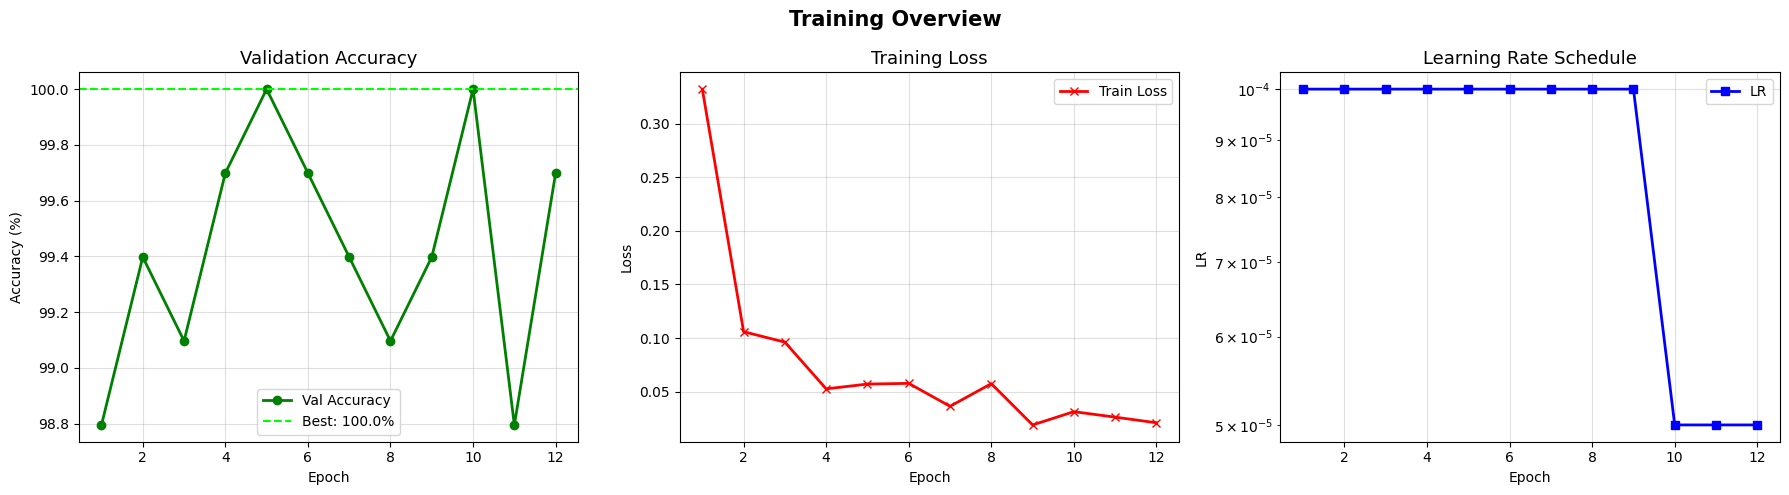

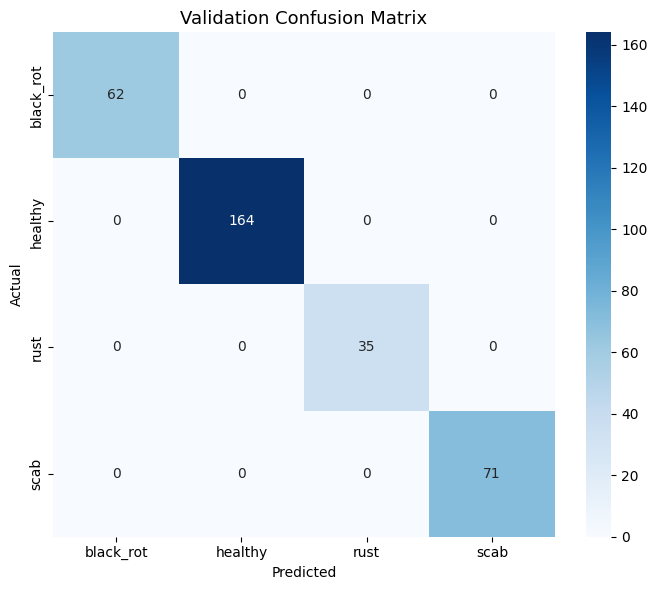

In [7]:
# ── Load best model for all evaluations ───────────────────────
model.load_state_dict(torch.load('model_best.pth', map_location=DEVICE))
model.eval()

epochs_ran = range(1, len(history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(epochs_ran, history['val_acc'],
             color='green', marker='o', linewidth=2, label='Val Accuracy')
axes[0].axhline(best_acc, color='lime', linestyle='--',
                label=f'Best: {best_acc:.1f}%')
axes[0].set_title('Validation Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Loss
axes[1].plot(epochs_ran, history['loss'],
             color='red', marker='x', linewidth=2, label='Train Loss')
axes[1].set_title('Training Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# Learning rate
axes[2].plot(epochs_ran, history['lr'],
             color='blue', marker='s', linewidth=2, label='LR')
axes[2].set_title('Learning Rate Schedule', fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.suptitle('Training Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Validation confusion matrix ───────────────────────────────
y_true_v, y_pred_v = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE)
        y_pred_v.extend(model(imgs).argmax(1).cpu().numpy())
        y_true_v.extend(lbls.numpy())

cm_val = confusion_matrix(y_true_v, y_pred_v)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.title('Validation Confusion Matrix', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 🎯 Cell 8 — Test Set Evaluation (Unbiased Final Score)


🎯 Test Accuracy : 98.51%
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

   black_rot       0.98      0.98      0.98        63
     healthy       1.00      0.99      1.00       165
        rust       0.92      0.97      0.95        36
        scab       0.99      0.97      0.98        72

    accuracy                           0.99       336
   macro avg       0.97      0.98      0.98       336
weighted avg       0.99      0.99      0.99       336



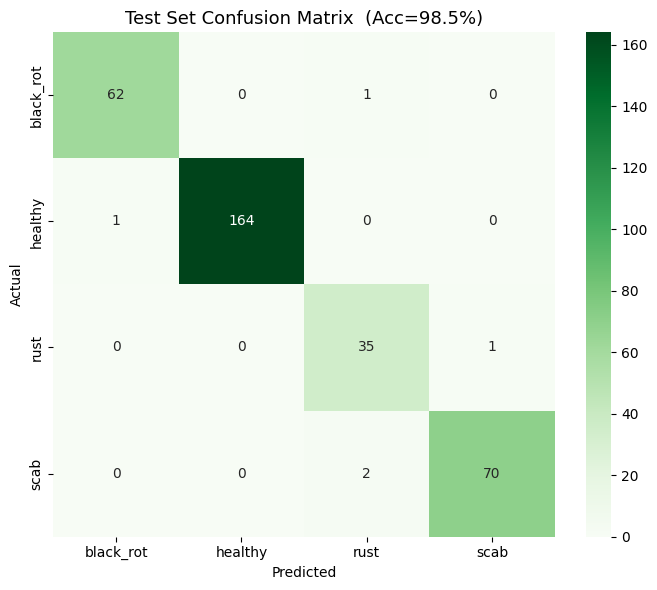

In [8]:
y_true_t, y_pred_t = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        y_pred_t.extend(model(imgs).argmax(1).cpu().numpy())
        y_true_t.extend(lbls.numpy())

test_acc = 100.0 * np.mean(np.array(y_pred_t) == np.array(y_true_t))
print(f'\n🎯 Test Accuracy : {test_acc:.2f}%')
print('─' * 55)
print(classification_report(y_true_t, y_pred_t,
                             target_names=train_ds.classes))

cm_test = confusion_matrix(y_true_t, y_pred_t)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.title(f'Test Set Confusion Matrix  (Acc={test_acc:.1f}%)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 🖥️ Cell 9 — Write Streamlit App

In [9]:
%%writefile app.py
"""
AppleAI Pro — Streamlit App
Run with:  streamlit run app.py
Requires:  model_best.pth in the same directory
"""
import os
import cv2
import numpy as np
import streamlit as st
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms


# ── 1. Grad-CAM engine ────────────────────────────────────────
class GradCAMEngine:
    """
    Grad-CAM with per-class severity thresholds.
    Target: m.features[-1][0]  (ConvBNActivation inside the last
    InvertedResidual block — NOT the Sequential wrapper, which
    breaks hooks silently on some PyTorch versions).
    """
    # Empirically tuned per-class activation thresholds
    THRESHOLDS = {
        'black_rot': 0.50,
        'rust'     : 0.38,
        'scab'     : 0.45,
        'healthy'  : 0.99,
    }

    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, _, __, out):        self.activations = out
    def _save_grad(self, _, __, grad_out):  self.gradients   = grad_out[0]

    def analyze(self, img_pil, label_idx, label_name):
        device = next(self.model.parameters()).device
        tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])
        inp = tf(img_pil).unsqueeze(0).to(device)
        inp.requires_grad_(True)

        self.model.zero_grad()
        out = self.model(inp)
        out[0, label_idx].backward()

        # Grad-CAM: global-average-pool the gradients → weight the activations
        grads   = self.gradients.detach().cpu().numpy()[0]   # (C,H,W)
        acts    = self.activations.detach().cpu().numpy()[0] # (C,H,W)
        weights = np.maximum(np.mean(grads, axis=(1, 2)), 0) # relu on weights
        cam     = np.sum(weights[:, None, None] * acts, axis=0)
        cam     = np.maximum(cam, 0)

        heatmap = cv2.resize(cam, (224, 224))
        if heatmap.max() > 0:
            heatmap /= heatmap.max()

        # Severity: diseased pixels / total leaf pixels
        img_np  = np.array(img_pil.resize((224, 224)))
        hsv     = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
        leaf_mask    = cv2.inRange(hsv, (5, 30, 30), (95, 255, 255))
        thr          = self.THRESHOLDS.get(label_name, 0.4)
        disease_mask = (heatmap > thr).astype(np.uint8) * 255
        leaf_px      = max(np.sum(leaf_mask > 0), 1)
        disease_px   = np.sum((disease_mask > 0) & (leaf_mask > 0))
        severity     = round(min(disease_px / leaf_px * 100, 100.0), 2)

        return heatmap, severity


# ── 2. Knowledge base ─────────────────────────────────────────
AGRI_DB = {
    'black_rot': {
        'med' : 'Mancozeb',
        'base': 550,
        'info': ('Prune infected branches immediately. '
                 'Apply copper-based fungicide after pruning. '
                 'Destroy all infected debris.'),
    },
    'healthy': {
        'med' : 'N/A',
        'base': 0,
        'info': ('No pathology detected. '
                 'Maintain current irrigation and fertilisation schedule.'),
    },
    'rust': {
        'med' : 'Myclobutanil',
        'base': 600,
        'info': ('Fungal spores detected. '
                 'Check for nearby Cedar or Juniper host trees. '
                 'Apply protective fungicide before rain events.'),
    },
    'scab': {
        'med' : 'Captan 80 WDG',
        'base': 450,
        'info': ('Apple scab thrives in humidity. '
                 'Increase canopy airflow via selective pruning. '
                 'Apply fungicide at green tip through petal fall.'),
    },
}

LABELS = ['black_rot', 'healthy', 'rust', 'scab']


# ── 3. Cached model loader ────────────────────────────────────
@st.cache_resource
def load_model(path='model_best.pth'):
    if not os.path.exists(path):
        return None, None
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m = models.mobilenet_v2(weights=None)
    m.classifier[1] = nn.Linear(m.last_channel, 4)
    m.load_state_dict(
        torch.load(path, map_location=device, weights_only=True)
    )
    m.eval().to(device)
    # FIX: hook ConvBNActivation inside last block, not the Sequential
    engine = GradCAMEngine(m, m.features[-1][0])
    return m, engine


# ── 4. Page layout ────────────────────────────────────────────
st.set_page_config(
    page_title='AppleAI Pro',
    page_icon='🍎',
    layout='wide',
)

st.title('🍎 AppleAI Pro: Automated Pathological Assessment')
st.caption('Integrated Computer Vision & Economic Estimator '
           'for Precision Apple Agriculture')
st.divider()

model, engine = load_model()

if model is None:
    st.error(
        "⚠️ **model_best.pth not found.**  "
        "Run the training notebook first, then re-launch this app."
    )
    st.stop()

# ── 5. Sidebar ────────────────────────────────────────────────
with st.sidebar:
    st.header('ℹ️ About')
    st.write(
        'Model: **MobileNetV2** fine-tuned on PlantVillage + PlantDoc.  \n'
        'XAI  : **Grad-CAM** lesion localisation.  \n'
        'Classes: Black Rot | Healthy | Rust | Scab'
    )
    st.divider()
    st.caption('Upload a clear photo of a single apple leaf.')

# ── 6. File upload & inference ────────────────────────────────
uploaded = st.file_uploader(
    'Upload Leaf Specimen',
    type=['jpg', 'jpeg', 'png'],
    help='JPG or PNG, ideally 224×224 px or larger'
)

if uploaded:
    img    = Image.open(uploaded).convert('RGB')
    device = next(model.parameters()).device

    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                              [0.229, 0.224, 0.225]),
    ])

    with torch.no_grad():
        logits   = model(tf(img).unsqueeze(0).to(device))
        probs    = torch.softmax(logits, 1)[0].cpu().numpy()
        idx      = int(probs.argmax())
        conf     = float(probs[idx])

    label    = LABELS[idx]
    heatmap, severity = engine.analyze(img, idx, label)
    db   = AGRI_DB[label]
    cost = int(db['base'] * (severity / 100 + 1)) if label != 'healthy' else 0

    # ── Columns ───────────────────────────────────────────────
    c1, c2, c3 = st.columns(3)

    with c1:
        st.subheader('📸 Original Leaf')
        st.image(img, use_container_width=True)
        st.metric('Diagnosis', label.replace('_', ' ').title())
        st.progress(conf, text=f'Confidence: {conf*100:.1f}%')

        # All-class probability bar chart
        import matplotlib.pyplot as _plt
        fig, ax = _plt.subplots(figsize=(4, 2.5))
        colors  = ['#e74c3c' if i == idx else '#95a5a6'
                   for i in range(4)]
        ax.barh(LABELS, probs * 100, color=colors)
        ax.set_xlabel('Probability (%)')
        ax.set_title('Class Probabilities')
        ax.set_xlim(0, 100)
        _plt.tight_layout()
        st.pyplot(fig)

    with c2:
        st.subheader('🔬 Grad-CAM Heatmap')
        img_np     = np.array(img.resize((224, 224)))
        heat_color = cv2.applyColorMap(
            np.uint8(255 * heatmap), cv2.COLORMAP_JET
        )
        overlay = cv2.addWeighted(
            img_np, 0.6,
            cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB), 0.4, 0
        )
        st.image(overlay, caption='Lesion Localisation',
                 use_container_width=True)

        sev_color = (
            '🟢' if severity < 20 else
            '🟡' if severity < 50 else '🔴'
        )
        st.metric('Severity Index', f'{severity}%',
                  delta=sev_color, delta_color='off')

    with c3:
        st.subheader('📋 Treatment Plan')
        st.metric('Estimated Treatment Cost', f'₹ {cost:,}')
        st.write(f'**Recommended Fungicide:** {db["med"]}')
        st.info(f'🌿 **Expert Note:** {db["info"]}')
        st.divider()
        if label == 'healthy':
            st.success('✅ Leaf is healthy. No treatment required.')
        else:
            st.warning(
                f'⚠️ **{label.replace("_"," ").title()}** detected  \n'
                f'Confidence: {conf*100:.1f}%  \n'
                f'Severity: {severity}%  \n'
                f'Treat with **{db["med"]}** — est. cost **₹ {cost:,}**'
            )

Writing app.py


## 🚀 Cell 10 — Launch App via ngrok

In [ ]:
# ════════════════════════════════════════════════
#  Cell 10 — Launch App via Cloudflare Tunnel
#  No account. No token. No firewall issues.
#  Copy-paste this entire cell into your notebook
# ════════════════════════════════════════════════

import subprocess, time, threading, re

# ── Kill any leftover Streamlit ───────────────────────────────
subprocess.run(['pkill', '-f', 'streamlit'],   capture_output=True)
subprocess.run(['pkill', '-f', 'cloudflared'], capture_output=True)
time.sleep(2)

# ── Install cloudflared binary ────────────────────────────────
get_ipython().system(
    'wget -q https://github.com/cloudflare/cloudflared/releases/latest/'
    'download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared '
    '&& chmod +x /usr/local/bin/cloudflared'
)
print('✅ cloudflared installed')

# ── Start Streamlit in background ────────────────────────────
get_ipython().system(
    'streamlit run app.py '
    '--server.port 8501 '
    '--server.headless true '
    '--server.enableCORS false '
    '--server.enableXsrfProtection false '
    '&> /tmp/streamlit.log &'
)
time.sleep(5)
print('✅ Streamlit started on port 8501')

# ── Start cloudflared tunnel, capture the public URL ─────────
url_found  = threading.Event()
public_url = {'value': None}

def run_tunnel():
    proc = subprocess.Popen(
        ['/usr/local/bin/cloudflared', 'tunnel',
         '--url', 'http://localhost:8501',
         '--no-autoupdate'],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    for line in proc.stdout:
        # cloudflared prints the URL in its log lines
        match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if match and not url_found.is_set():
            public_url['value'] = match.group(0)
            url_found.set()
        if url_found.is_set():
            # Keep process alive but stop scanning lines
            proc.wait()
            break

tunnel_thread = threading.Thread(target=run_tunnel, daemon=True)
tunnel_thread.start()

# ── Wait up to 30s for the URL ────────────────────────────────
print('⏳ Waiting for tunnel URL ...')
found = url_found.wait(timeout=30)

print()
if found:
    print('=' * 60)
    print('  🍎 AppleAI is LIVE!')
    print('=' * 60)
    print(f'  👉  {public_url["value"]}')
    print()
    print('  • Click the link above — app opens directly.')
    print('  • No password, no CAPTCHA.')
    print('  • To stop: Runtime → Interrupt execution')
    print('=' * 60)
else:
    print('❌ Tunnel URL not found in 30s.')
    print('   Check Streamlit logs:')
    get_ipython().system('tail -20 /tmp/streamlit.log')

# ── Keep cell alive so tunnel stays open ─────────────────────
try:
    while True:
        time.sleep(60)
except KeyboardInterrupt:
    print('Tunnel closed.')

✅ cloudflared installed
✅ Streamlit started on port 8501
⏳ Waiting for tunnel URL ...

  🍎 AppleAI is LIVE!
  👉  https://suggest-aquatic-taylor-bit.trycloudflare.com

  • Click the link above — app opens directly.
  • No password, no CAPTCHA.
  • To stop: Runtime → Interrupt execution
